# Sliding time window EBBlayer

This tutorial demonstrates the need for a sliding window, layer-specific version of EBB reconstruction to accurately infer two distinct laminar sources across time and space. It builds on the laminar CSD tutorial and addresses limitations, as well as best practices for using EBB for laminar inference.

It is composed of two parts: one adressing the need for sliding windows and the other for EBBlayer, a version of EBB that accounts for correlated sources across layers.

Two sources are simulated, one in superficial and one in deep layers, either consecutively or simultaneously. Source reconstruction is performed on the simulated sensor data using a forward model based on the multilayer mesh, first on the whole time window using EBB, then using a sliding time window EBB, an finally using a sliding time window with a modified version of EBB with specific priors accounting for correlated sources across layers. Laminar CSD analysis is then run on the laminar source reconstructed signals at the location of the peak variance.

## Part I: Temporal smoothing effect: the need for sliding time windows

### Setting up the simulations

Simulations are based on an existing dataset, which is used to define the sampling rate, number of trials, duration of each trial, and the channel layout.

In [2]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tempfile
from IPython.display import Image
import base64

from lameg.invert import invert_ebb, invert_sliding_window_ebb, invert_sliding_window_ebb_layer, coregister, load_source_time_series
from lameg.laminar import compute_csd
from lameg.simulate import run_current_density_simulation
from lameg.surf import LayerSurfaceSet
from lameg.util import get_fiducial_coords, load_meg_sensor_data, init_spm_parallel_pool
from lameg.viz import show_surface, color_map, plot_csd
import spm_standalone

# Subject information for data to base the simulations on
subj_id = 'sub-104'
ses_id = 'ses-01'

# Fiducial coil coordinates
fid_coords = get_fiducial_coords(subj_id, '../test_data/participants.tsv')

# Data file to base simulations on
data_file = os.path.join(
    '../test_data', 
    subj_id,
    'meg',
    ses_id,
    f'spm/pspm-converted_autoreject-{subj_id}-{ses_id}-001-btn_trial-epo.mat'
)

%env SUBJECTS_DIR=../test_data/fs

spm = spm_standalone.initialize()
init_spm_parallel_pool(spm, 16)

env: SUBJECTS_DIR=../test_data/fs
SPM, version dev (standalone)
MATLAB, version 9.6.0.1472908 (R2019a) Update 9
 ___  ____  __  __                                            
/ __)(  _ \(  \/  )                                           
\__ \ )___/ )    (   Statistical Parametric Mapping           
(___/(__)  (_/\/\_)  SPM - https://www.fil.ion.ucl.ac.uk/spm/

Starting parallel pool (parpool) using the 'local' profile ...
Connected to the parallel pool (number of workers: 16).


The simulations and source reconstructions will be based on a forward model using the multilayer mesh, with 11 layers

In [3]:
surf_set = LayerSurfaceSet(subj_id, 11)

verts_per_surf = surf_set.get_vertices_per_layer()

We’re going to copy the data file to a temporary directory and direct all output there.

In [4]:
# Extract base name and path of data file
data_path, data_file_name = os.path.split(data_file)
data_base = os.path.splitext(data_file_name)[0]

# Where to put simulated data
tmp_dir = tempfile.mkdtemp()

# Copy data files to tmp directory
if not os.path.exists(tmp_dir):
   os.mkdir(tmp_dir)

# Copy data files to tmp directory
shutil.copy(
    os.path.join(data_path, f'{data_base}.mat'),
    os.path.join(tmp_dir, f'{data_base}.mat')
)
shutil.copy(
    os.path.join(data_path, f'{data_base}.dat'),
    os.path.join(tmp_dir, f'{data_base}.dat')
)

# Construct base file name for simulations
base_fname = os.path.join(tmp_dir, f'{data_base}.mat')

Invert the subject’s data using the multilayer mesh. This step only has to be done once - this is just to compute the forward model that will be used in the simulations

In [5]:
# Patch size to use for inversion (in this case it matches the simulated patch size)
patch_size = 5
# Number of temporal modes to use for EBB inversion
n_temp_modes = 4

# Coregister data to multilayer mesh
coregister(
    fid_coords,
    base_fname,
    surf_set,
    spm_instance=spm
)

# Run inversion
[_,_] = invert_ebb(
    base_fname,
    surf_set,
    patch_size=patch_size,
    n_temp_modes=n_temp_modes,
    spm_instance=spm
)

SPM, version dev (standalone)
MATLAB, version 9.6.0.1472908 (R2019a) Update 9
 ___  ____  __  __                                            
/ __)(  _ \(  \/  )                                           
\__ \ )___/ )    (   Statistical Parametric Mapping           
(___/(__)  (_/\/\_)  SPM - https://www.fil.ion.ucl.ac.uk/spm/

Initialising batch system... done.


------------------------------------------------------------------------
19-Mar-2026 19:36:22 - Running job #1
------------------------------------------------------------------------
19-Mar-2026 19:36:22 - Running 'Head model specification'

SPM: spm_eeg_inv_mesh_ui                           19:36:23 - 19/03/2026
multilayer.11.ds.link_vector.fixed
undoing the G3BR balancing for the gradiometer definition
creating layout from cfg.grad
undoing the G3BR balancing for the gradiometer definition
creating layout for ctf275 system

SPM: spm_eeg_inv_forward                           19:37:46 - 19/03/2026
Completed                   

### Simulating two sources in different layers

In other tutorials we explored the case of a single laminar source but in real data, we might expect several consecutive sources in different layers. 

We’re going to simulate 200ms of 2 Gaussian with a dipole moment of 5nAm, a width of 25ms, the second one occuring 80ms after the first

In [6]:
_, time, _ = load_meg_sensor_data(base_fname)
print(f'Time from {time[0]} to {time[-1]}, with shape {time.shape}')

Time from -99.99999999999997 to 100.00000000000003, with shape (121,)


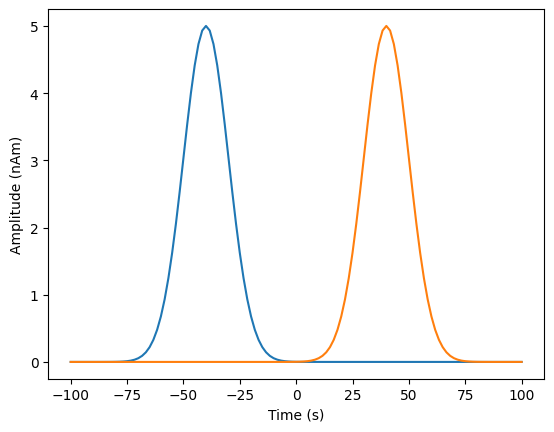

In [7]:
# Strength of simulated activity (nAm)
dipole_moment = 5
# Temporal width of the simulated Gaussian
signal_width= 10 # 25ms
# Sampling rate (must match the data file)
s_rate = 600

zero_time1=-40
zero_time2=40
sim_signal1=np.exp(-((time-zero_time1)**2)/(2*signal_width**2)).reshape(1,-1)
sim_signal2=np.exp(-((time-zero_time2)**2)/(2*signal_width**2)).reshape(1,-1)
plt.plot(time,dipole_moment*sim_signal1[0,:],label='sim1')
plt.plot(time,dipole_moment*sim_signal2[0,:],label='sim2')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (nAm)')

Select the best vertex to simulate at (based on anatomical measures), and get the corresponding layer vertices. See other tutorials. 

In [8]:
# Vertex to simulate activity at
sim_vertex=10561
sim_vertices = [
    surf_set.get_multilayer_vertex(1, sim_vertex), # simulating in superficial
    surf_set.get_multilayer_vertex(9, sim_vertex) # simulating in deep
]

We’ll simulate a 5mm patch of activity with -5 dB SNR at the sensor level. The desired level of SNR is achieved by adding white noise to the projected sensor signals

In [9]:
# Size of simulated patch of activity (mm)
sim_patch_size = 5
# SNR of simulated data (dB)
SNR = -5

prefix = f'sim_{sim_vertex}_'

# Generate simulated data
sim_fname = run_current_density_simulation(
    base_fname, 
    prefix, 
    sim_vertices, 
    np.vstack([sim_signal1, sim_signal2]), 
    [dipole_moment, dipole_moment], 
    [sim_patch_size, sim_patch_size], 
    SNR,
    average_trials=True,
    spm_instance=spm
)  

Simulating data on MEG channels only
Using closest mesh vertices to the specified coordinates
Furthest distance from dipole location to mesh 0.00 mm

ans =

    'm'

SIMULATING CURRENT DISTRIBUTIONS ON MESH
Computing Gain Matrix:  - done
Saving prior in directory /home/bonaiuto/tmp/tmp4mj9bd0q/simprior_sim_10561_pspm-converted_autoreject-sub-104-ses-01-001-btn_trial-epo
Using 1 iterations of 2 fixed patches

 In last iteration...setting up patch 1 with  5.00 nAm , FWHM 5.00mm, mean moment density 263.06 pAm/mm2, peak momemnt density 560.96 pAm/mm2 

 In last iteration...setting up patch 2 with  5.00 nAm , FWHM 5.00mm, mean moment density 257.31 pAm/mm2, peak momemnt density 599.35 pAm/mm2 
Prior 1. Average Mean (over dist of FWHM from centre) moment density 260.18, sd 4.06 pAm/mm2
Prior 1. Average Peak (max vertex) moment density 580.15, sd 27.15 pAm/mm2
Saving /home/bonaiuto/tmp/tmp4mj9bd0q/simprior_sim_10561_pspm-converted_autoreject-sub-104-ses-01-001-btn_trial-epo/prior331073.mat
S

### Inversion

Now we’ll run a source reconstruction using the multilayer mesh, select the vertex to examine, extract the source signals at each layer in that location, and compute a laminar CSD

#### Inversion on the full time window 

We will first look at the behavior of inverting the full window with the basic EBB algorithm

In [10]:
[_,_, MU] = invert_ebb(
    sim_fname,
    surf_set,
    patch_size=patch_size,
    n_temp_modes=n_temp_modes,
    return_mu_matrix= True,
    spm_instance=spm
)

Smoothing ../test_data/fs/sub-104/surf/laminar/multilayer.11.ds.link_vector.fixed.gii

smoothmeshname =

    '../test_data/fs/sub-104/surf/laminar/FWHM5.00_multilayer.11.ds.link_vector.fixed.mat'


Found smoothfile ../test_data/fs/sub-104/surf/laminar/FWHM5.00_multilayer.11.ds.link_vector.fixed.mat, not recomputing
Removed 0 bad channels

Taking random selections of 0.00 percent of channels
Using 0 spatial modes

Preparing modes file  block 1 of 1 for 274 training and 0 test chans

 saving spatial mode file /home/bonaiuto/tmp/tmp4mj9bd0q/msim_10561_pspm-converted_autoreject-sub-104-ses-01-001-btn_trial-epo_testmodes.mat
SPM, version dev (standalone)
MATLAB, version 9.6.0.1472908 (R2019a) Update 9
 ___  ____  __  __                                            
/ __)(  _ \(  \/  )                                           
\__ \ )___/ )    (   Statistical Parametric Mapping           
(___/(__)  (_/\/\_)  SPM - https://www.fil.ion.ucl.ac.uk/spm/



----------------------------------------

In [11]:
pial_layer_vertices = np.arange(verts_per_surf)
pial_layer_ts, time, _ = load_source_time_series(
    sim_fname,
    vertices=pial_layer_vertices
)

# Peak
mean_pial_layer_ts = np.mean(pial_layer_ts,axis=-1)
peak = np.argmax(mean_pial_layer_ts)

print(f'Simulated vertex={sim_vertex}, Prior vertex={peak}')

Simulated vertex=10561, Prior vertex=10561


We can see that the peak is at the same location we simulated at

In [12]:
# Plot colors and camera view
max_abs = np.max(np.abs(mean_pial_layer_ts))
c_range = [-max_abs, max_abs]

# Plot peak
colors,_ = color_map(
    mean_pial_layer_ts,
    "RdYlBu_r",
    c_range[0],
    c_range[1]
)
thresh_colors=np.ones((colors.shape[0],4))*255
thresh_colors[:,:3]=colors
thresh_colors[mean_pial_layer_ts<np.percentile(mean_pial_layer_ts,99.9),3]=0

cam_view = [40, -240, 25,
            60, 37, 17,
            0, 0, 1]

plot = show_surface(
    surf_set,
    vertex_colors=thresh_colors,
    info=True,
    camera_view=cam_view,
    marker_vertices=peak,
    marker_size=3,
    marker_color=[0,0,255]
)

Output()

51091 vertices


In [17]:
plot.fetch_screenshot()

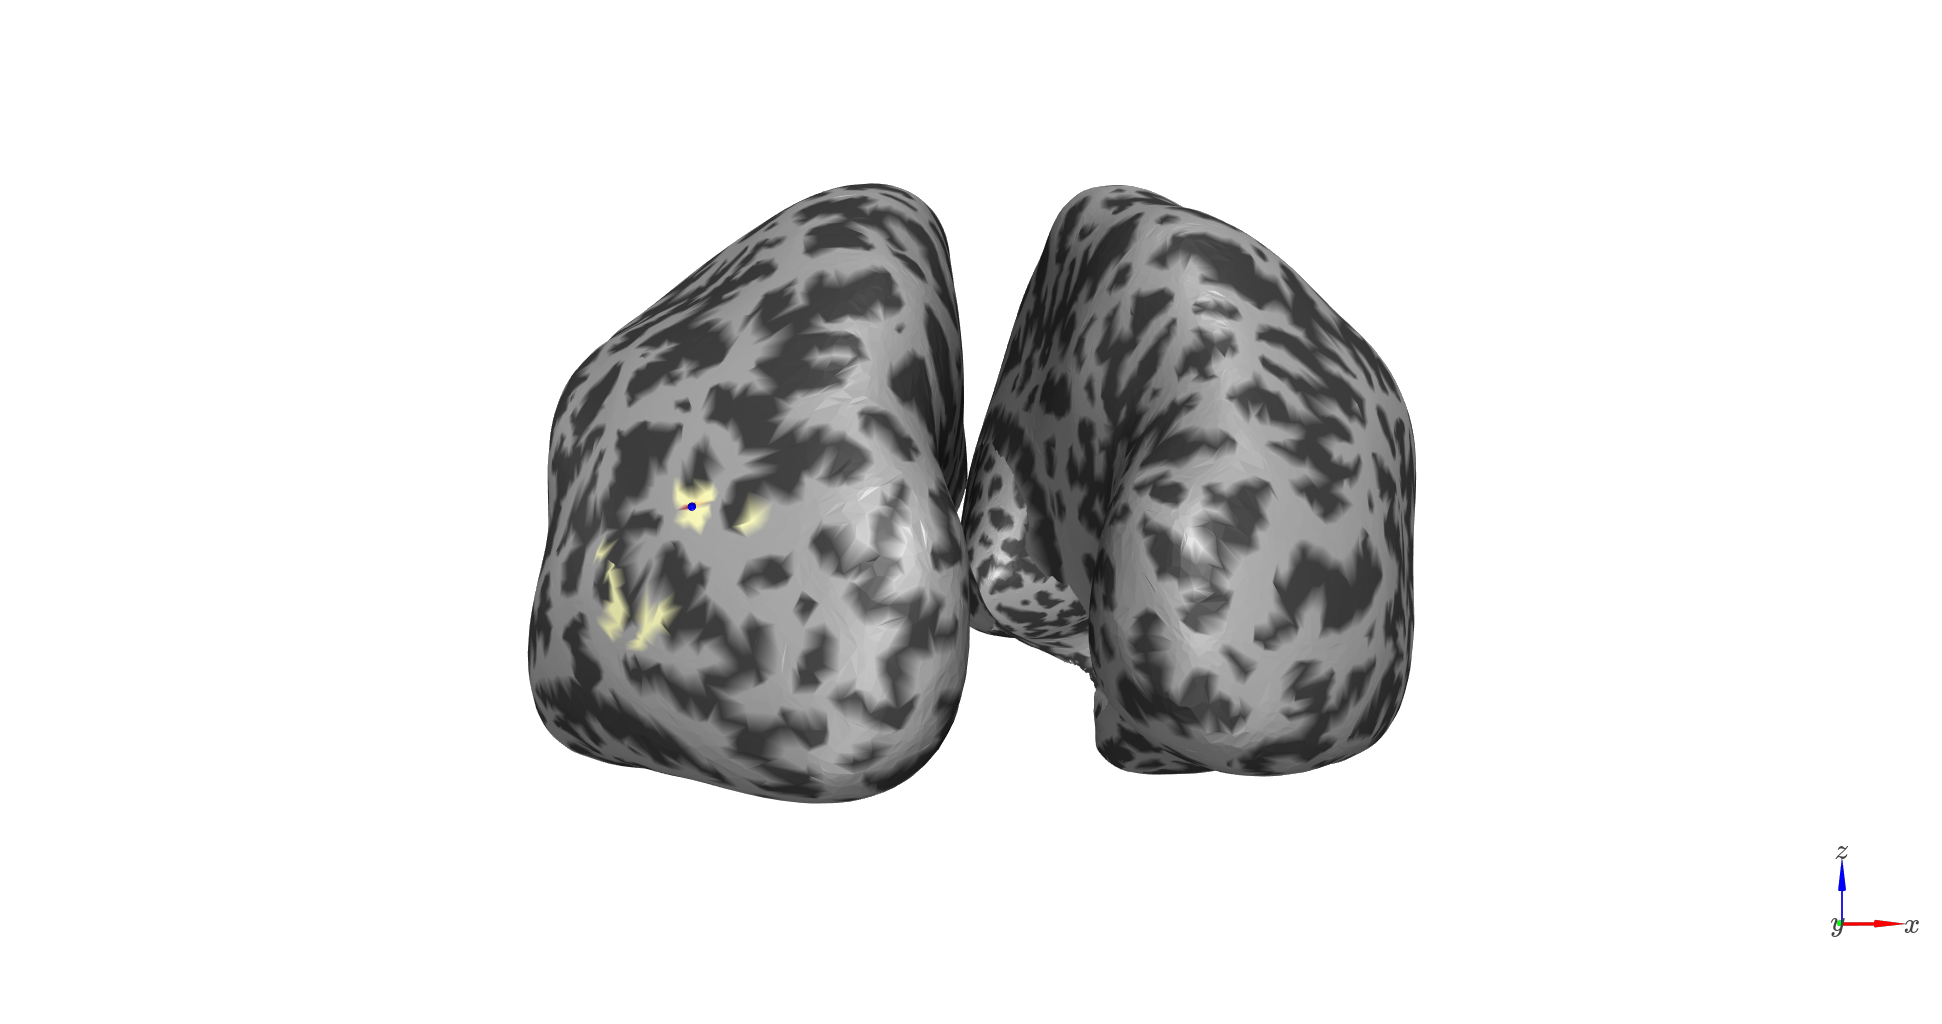

In [18]:
Image(data=base64.b64decode(plot.screenshot))

We need the indices of the vertex at each layer for this location, and the distances between them

In [13]:
# first retreiving the distance between layers of the maximum peak
layer_verts = surf_set.get_layer_vertices(peak)
layer_dists = surf_set.get_interlayer_distance(peak)
print(layer_dists)

[0.57684296 0.5554792  0.5554103  0.55534863 0.55528706 0.5552514
 0.55520284 0.55516315 0.5553267  0.5566609 ]


Now we can compute and plot the laminar CSD

In [14]:
# Set a function for loading the time series, computing CSD and plotting
def load_and_plot_csd(sim_fname, surf_set, layer_verts, layer_dists, MU=None):
    # Get source time series for each layer (already averaged)
    if MU is not None:
        mean_layer_ts, time, _ = load_source_time_series(sim_fname, mu_matrix=MU, vertices=layer_verts)
    else: 
        mean_layer_ts, time, _ = load_source_time_series(sim_fname, vertices=layer_verts)
        
    csd = compute_csd(mean_layer_ts, np.sum(layer_dists), s_rate, method='KCSD1D')
    
    col_r = plt.cm.cool(np.linspace(0,1, num=surf_set.n_layers))
    plt.figure(figsize=(15,4))
    plt.subplot(1,3,1)
    for l in range(surf_set.n_layers):
        plt.plot(time, mean_layer_ts[l,:], label=f'{l}', color=col_r[l,:])
    plt.legend(loc='upper left')
    plt.xlabel('Time (ms)')
    plt.ylabel('Source (nAm)')

    plt.subplot(1,3,2)
    col_r = plt.cm.cool(np.linspace(0,1, num=csd.shape[0]))
    for l in range(csd.shape[0]):
        plt.plot(time, csd[l,:], color=col_r[l,:])
    plt.xlabel('Time (ms)')
    plt.ylabel('CSD')

    ax=plt.subplot(1,3,3)
    plot_csd(csd, time, ax, n_layers=surf_set.n_layers)
    plt.xlabel('Time (ms)')
    plt.ylabel('Layer')
    plt.tight_layout()

No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.0011006941712522092


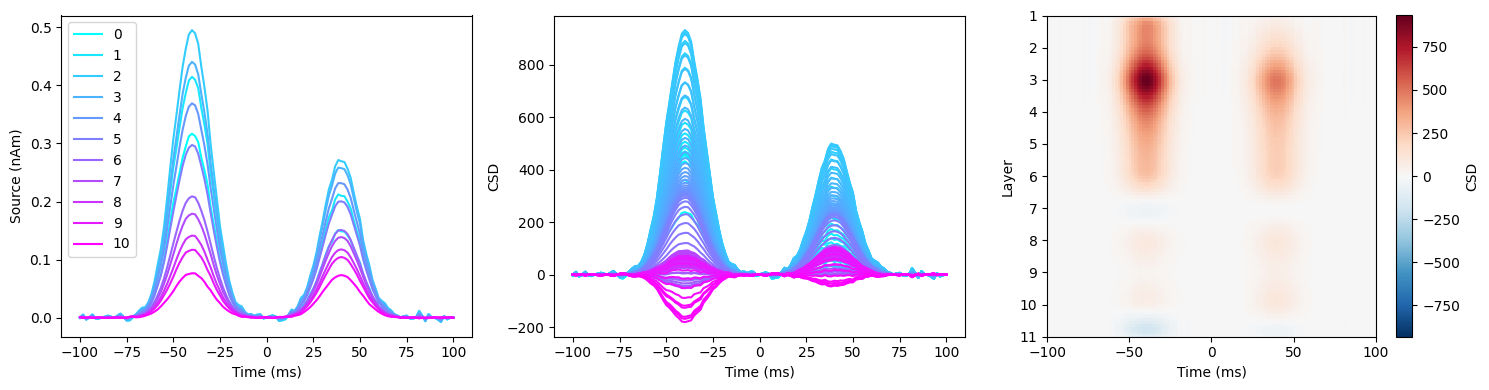

In [15]:
load_and_plot_csd(sim_fname, surf_set, layer_verts, layer_dists, MU=MU)

We can observe that the two sources are not separated spatially, we do not retreive the layers we simulated at. Note that the amplitude difference in the second source comes from the source being deep and further away from the surface. 

#### Inversion with a sliding window

We then reconstruct layer source time series using a sliding time window of 25ms.

In [16]:
# a modified version of invert_ebb using sliding time windows
[_,_] = invert_sliding_window_ebb(
    sim_fname,
    surf_set,
    patch_size=patch_size,
    n_temp_modes=n_temp_modes,
    win_size=25,
    win_overlap=True,
    spm_instance=spm
)

Smoothing ../test_data/fs/sub-104/surf/laminar/multilayer.11.ds.link_vector.fixed.gii

smoothmeshname =

    '../test_data/fs/sub-104/surf/laminar/FWHM5.00_multilayer.11.ds.link_vector.fixed.mat'


Found smoothfile ../test_data/fs/sub-104/surf/laminar/FWHM5.00_multilayer.11.ds.link_vector.fixed.mat, not recomputing
Removed 0 bad channels

Taking random selections of 0.00 percent of channels
Using 0 spatial modes

Preparing modes file  block 1 of 1 for 274 training and 0 test chans

 saving spatial mode file /home/bonaiuto/tmp/tmp4mj9bd0q/msim_10561_pspm-converted_autoreject-sub-104-ses-01-001-btn_trial-epo_testmodes.mat
SPM, version dev (standalone)
MATLAB, version 9.6.0.1472908 (R2019a) Update 9
 ___  ____  __  __                                            
/ __)(  _ \(  \/  )                                           
\__ \ )___/ )    (   Statistical Parametric Mapping           
(___/(__)  (_/\/\_)  SPM - https://www.fil.ion.ucl.ac.uk/spm/



----------------------------------------

  ReML Iteration 1                      :        ...2.059546e+01 [+4.12]
  ReML Iteration 2                      :        ...1.296636e+01 [+4.25]
  ReML Iteration 3                      :        ...7.258445e+00 [+4.38]
  ReML Iteration 4                      :        ...2.785997e+00 [+4.50]
  ReML Iteration 5                      :        ...7.048138e-02 [+4.62]
  ReML Iteration 6                      :        ...5.172302e-06 [+4.75]
Percent variance explained 1.26 (0.94)
  ReML Iteration 1                      :        ...2.251587e+01 [+4.12]
  ReML Iteration 2                      :        ...1.224754e+01 [+4.25]
  ReML Iteration 3                      :        ...4.727239e+00 [+4.38]
  ReML Iteration 4                      :        ...9.190389e-01 [+4.50]
  ReML Iteration 5                      :        ...4.758107e-02 [+4.62]
  ReML Iteration 6                      :        ...5.305188e-02 [+3.62]
  ReML Iteration 7                      :        ...5.025948e-06 [+3.75]
Percent vari

  ReML Iteration 1                      :        ...2.043775e+01 [+4.12]
  ReML Iteration 2                      :        ...1.239432e+01 [+4.25]
  ReML Iteration 3                      :        ...6.138377e+00 [+4.38]
  ReML Iteration 4                      :        ...1.810459e+00 [+4.50]
  ReML Iteration 5                      :        ...2.186071e-03 [+4.62]
Percent variance explained 2.71 (2.39)
Number of samples 7
Fixed number of temporal modes
Using 4 temporal modes, accounting for 97.58 percent average variance
NB smooth EBB algorithm !
Using 1 spatial source priors provided
  ReML Iteration 1                      :        ...1.869000e+01 [+4.12]
  ReML Iteration 2                      :        ...1.219896e+01 [+4.25]
  ReML Iteration 3                      :        ...7.402797e+00 [+4.38]
  ReML Iteration 4                      :        ...3.483205e+00 [+4.50]
  ReML Iteration 5                      :        ...1.095667e-01 [+4.62]
  ReML Iteration 6                      :    

Fixed number of temporal modes
Using 4 temporal modes, accounting for 99.98 percent average variance
NB smooth EBB algorithm !
Using 1 spatial source priors provided
  ReML Iteration 1                      :        ...1.736012e+02 [+4.12]
  ReML Iteration 2                      :        ...1.641973e+02 [+4.25]
  ReML Iteration 3                      :        ...1.539426e+02 [+4.38]
  ReML Iteration 4                      :        ...1.415909e+02 [+4.50]
  ReML Iteration 5                      :        ...2.777873e+01 [+4.62]
  ReML Iteration 6                      :        ...2.454474e-01 [+4.75]
  ReML Iteration 7                      :        ...7.567775e-02 [+4.88]
  ReML Iteration 8                      :        ...2.029486e-02 [+5.00]
  ReML Iteration 9                      :        ...5.894484e-03 [+5.12]
Inverting subject 1
  ReML Iteration 1                      :        ...1.738795e+02 [+4.12]
  ReML Iteration 2                      :        ...1.646706e+02 [+4.25]
  ReML Iter

  ReML Iteration 1                      :        ...1.745170e+02 [+4.12]
  ReML Iteration 2                      :        ...1.655882e+02 [+4.25]
  ReML Iteration 3                      :        ...1.560408e+02 [+4.38]
  ReML Iteration 4                      :        ...1.449138e+02 [+4.50]
  ReML Iteration 5                      :        ...2.994467e+01 [+4.62]
  ReML Iteration 6                      :        ...3.143832e-01 [+4.75]
  ReML Iteration 7                      :        ...1.119189e-01 [+4.88]
  ReML Iteration 8                      :        ...3.437103e-02 [+5.00]
  ReML Iteration 9                      :        ...1.156030e-02 [+5.12]
  ReML Iteration 10                     :        ...3.700950e-03 [+5.25]
Percent variance explained 99.97 (99.95)
  ReML Iteration 1                      :        ...1.370699e+02 [+4.12]
  ReML Iteration 2                      :        ...9.585637e+01 [+4.25]
  ReML Iteration 3                      :        ...4.383605e+01 [+4.38]
  ReML Ite

...

  ReML Iteration 1                      :        ...1.760948e+02 [+4.12]
  ReML Iteration 2                      :        ...1.677653e+02 [+4.25]
  ReML Iteration 3                      :        ...1.585515e+02 [+4.38]
  ReML Iteration 4                      :        ...1.471654e+02 [+4.50]
  ReML Iteration 5                      :        ...3.118174e+01 [+4.62]
  ReML Iteration 6                      :        ...2.989573e-01 [+4.75]
  ReML Iteration 7                      :        ...1.195127e-01 [+4.88]
  ReML Iteration 8                      :        ...4.153747e-02 [+5.00]
  ReML Iteration 9                      :        ...1.581409e-02 [+5.12]
  ReML Iteration 10                     :        ...5.712165e-03 [+5.25]
Percent variance explained 99.95 (99.91)
  ReML Iteration 2                      :        ...1.601080e+02 [+4.25]
  ReML Iteration 3                      :        ...1.451395e+02 [+4.38]
  ReML Iteration 4                      :        ...1.214227e+02 [+4.50]
  ReML Ite

  ReML Iteration 2                      :        ...1.601080e+02 [+4.25]
  ReML Iteration 3                      :        ...1.451395e+02 [+4.38]
  ReML Iteration 4                      :        ...1.214227e+02 [+4.50]
  ReML Iteration 5                      :        ...1.690073e+01 [+4.62]
  ReML Iteration 6                      :        ...1.082799e-04 [+4.75]
Percent variance explained 99.76 (99.24)
Number of samples 9
Number of samples 12
  ReML Iteration 2                      :        ...1.567310e+02 [+4.25]
  ReML Iteration 3                      :        ...1.383106e+02 [+4.38]
  ReML Iteration 4                      :        ...1.081710e+02 [+4.50]
  ReML Iteration 5                      :        ...8.197215e+00 [+4.62]
  ReML Iteration 6                      :        ...3.065429e-02 [+4.75]
  ReML Iteration 7                      :        ...7.213273e-04 [+4.88]
Inverting subject 1
Number of samples 8
  ReML Iteration 2                      :        ...1.519418e+02 [+4.25]
  

  ReML Iteration 1                      :        ...1.967056e+01 [+4.12]
  ReML Iteration 2                      :        ...1.229741e+01 [+4.25]
  ReML Iteration 3                      :        ...6.721339e+00 [+4.38]
  ReML Iteration 4                      :        ...2.679167e+00 [+4.50]
  ReML Iteration 5                      :        ...4.504967e-02 [+4.62]
  ReML Iteration 6                      :        ...1.938404e-06 [+4.75]
Inverting subject 1
Number of samples 15
Fixed number of temporal modes
Using 4 temporal modes, accounting for 71.68 percent average variance
NB smooth EBB algorithm !
Using 1 spatial source priors provided
  ReML Iteration 1                      :        ...1.967056e+01 [+4.12]
  ReML Iteration 2                      :        ...1.229741e+01 [+4.25]
  ReML Iteration 3                      :        ...6.721339e+00 [+4.38]
  ReML Iteration 4                      :        ...2.679167e+00 [+4.50]
  ReML Iteration 5                      :        ...4.504967e-0

  ReML Iteration 1                      :        ...1.295685e+02 [+4.12]
  ReML Iteration 2                      :        ...7.927267e+01 [+4.25]
  ReML Iteration 3                      :        ...2.453702e+01 [+4.38]
  ReML Iteration 4                      :        ...1.531425e+00 [+4.50]
  ReML Iteration 5                      :        ...4.410279e-03 [+4.62]
Inverting subject 1
Number of samples 11
Fixed number of temporal modes
Using 4 temporal modes, accounting for 83.73 percent average variance
NB smooth EBB algorithm !
Using 1 spatial source priors provided
  ReML Iteration 1                      :        ...2.092479e+01 [+4.12]
  ReML Iteration 2                      :        ...1.312532e+01 [+4.25]
  ReML Iteration 3                      :        ...7.411605e+00 [+4.38]
  ReML Iteration 4                      :        ...3.155195e+00 [+4.50]
  ReML Iteration 5                      :        ...1.119668e-01 [+4.62]
  ReML Iteration 6                      :        ...1.401540e-0

IdleTimeout has been reached.
Parallel pool using the 'local' profile is shutting down.
19-Mar-2026 21:30:03 - Done    'Source inversion, iterative'
19-Mar-2026 21:30:03 - Done



Then, we extract the time series and compute the laminar CSD

No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01


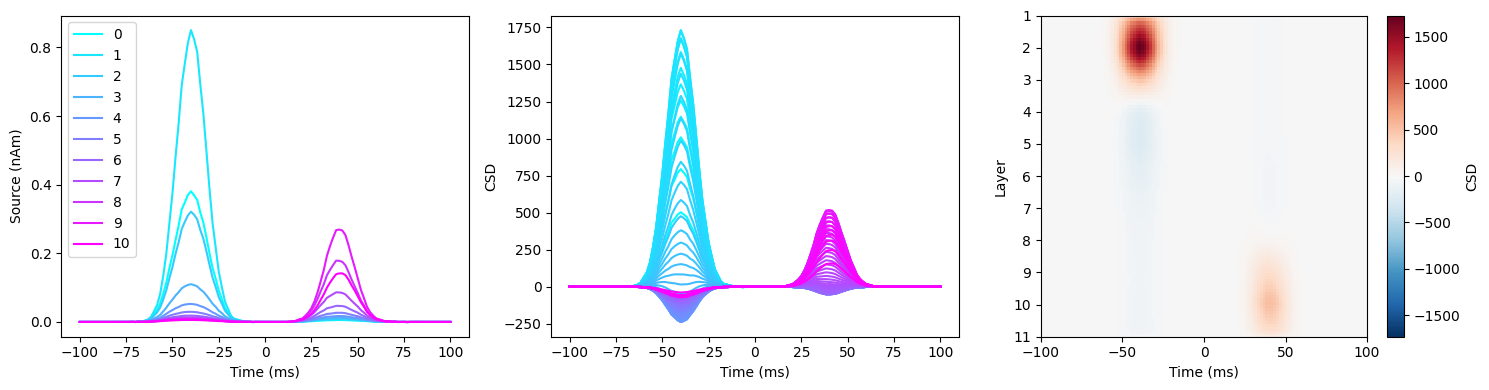

In [17]:
load_and_plot_csd(sim_fname, surf_set, layer_verts, layer_dists)

Here the spatiotemporal dynamics of layer activity are accurately reconstructed.

**Explanation:** The empirical Bayesian beamformer uses a sensor covariance matrix to compute its inversion. When inverting on the whole window, the covariance contains both deep and superficial layer activity, that have extremely similar leadfields, and it collapses into a compromise between the two. It then sees a dominant spatial pattern, for the whole time window. If we invert with a sliding time window, we get only one laminar source at a time, spatially decorrelated. But keep in mind that temporal and spatial discrimination of laminar sources strongly depends on the width of your reconstructed window. If you use too small a time window, you don't get enough time samples to build an accurate covariance matrix.

## Part II: Correlated sources across layers: the need for layer-specific spatial source priors

### Simulating two simultaneous sources

Here we simulate two sources - one in a superficial layer and one in a deep layer (as before) but occuring at the same time. We keep the same SNR = -5bB and dipole moment 5nAm as previously. 

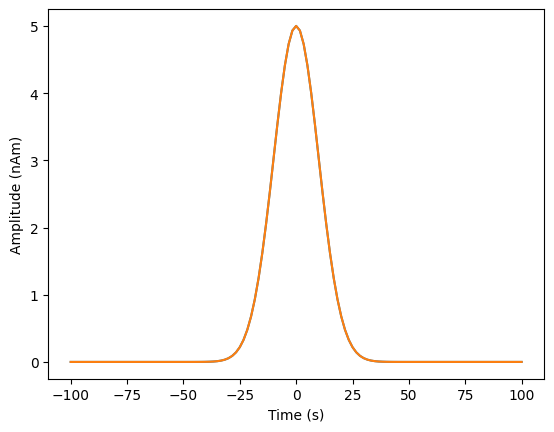

In [18]:
zero_time_1new=0
zero_time_2new=0
sim_signal1_new=np.exp(-((time-zero_time_1new)**2)/(2*signal_width**2)).reshape(1,-1)
sim_signal2_new=np.exp(-((time-zero_time_2new)**2)/(2*signal_width**2)).reshape(1,-1)
plt.plot(time,dipole_moment*sim_signal1_new[0,:],label='sim1')
plt.plot(time,dipole_moment*sim_signal2_new[0,:],label='sim2')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (nAm)')

In [19]:
prefix_2 = f'sim2_{sim_vertex}_'

# Generate simulated data
sim_fname_2 = run_current_density_simulation(
    base_fname, 
    prefix_2, 
    sim_vertices, 
    np.vstack([sim_signal1_new, sim_signal2_new]), 
    [dipole_moment, dipole_moment], 
    [sim_patch_size, sim_patch_size], 
    SNR,
    average_trials=True,
    spm_instance=spm
)  

Simulating data on MEG channels only
Using closest mesh vertices to the specified coordinates
Furthest distance from dipole location to mesh 0.00 mm

ans =

    'm'

SIMULATING CURRENT DISTRIBUTIONS ON MESH
Computing Gain Matrix:  - done
Saving prior in directory /home/bonaiuto/tmp/tmp4mj9bd0q/simprior_sim2_10561_pspm-converted_autoreject-sub-104-ses-01-001-btn_trial-epo
Using 1 iterations of 2 fixed patches

 In last iteration...setting up patch 1 with  5.00 nAm , FWHM 5.00mm, mean moment density 263.06 pAm/mm2, peak momemnt density 560.96 pAm/mm2 

 In last iteration...setting up patch 2 with  5.00 nAm , FWHM 5.00mm, mean moment density 257.31 pAm/mm2, peak momemnt density 599.35 pAm/mm2 
Prior 1. Average Mean (over dist of FWHM from centre) moment density 260.18, sd 4.06 pAm/mm2
Prior 1. Average Peak (max vertex) moment density 580.15, sd 27.15 pAm/mm2
Saving /home/bonaiuto/tmp/tmp4mj9bd0q/simprior_sim2_10561_pspm-converted_autoreject-sub-104-ses-01-001-btn_trial-epo/prior331073.mat

### Inversion with basic sliding window EBB

In [20]:
[_,_] = invert_sliding_window_ebb(
    sim_fname_2,
    surf_set,
    patch_size=patch_size,
    n_temp_modes=n_temp_modes,
    win_size=25,
    win_overlap=True,
    spm_instance=spm
)

Smoothing ../test_data/fs/sub-104/surf/laminar/multilayer.11.ds.link_vector.fixed.gii

smoothmeshname =

    '../test_data/fs/sub-104/surf/laminar/FWHM5.00_multilayer.11.ds.link_vector.fixed.mat'


Found smoothfile ../test_data/fs/sub-104/surf/laminar/FWHM5.00_multilayer.11.ds.link_vector.fixed.mat, not recomputing
Removed 0 bad channels

Taking random selections of 0.00 percent of channels
Using 0 spatial modes

Preparing modes file  block 1 of 1 for 274 training and 0 test chans

 saving spatial mode file /home/bonaiuto/tmp/tmp4mj9bd0q/msim2_10561_pspm-converted_autoreject-sub-104-ses-01-001-btn_trial-epo_testmodes.mat
SPM, version dev (standalone)
MATLAB, version 9.6.0.1472908 (R2019a) Update 9
 ___  ____  __  __                                            
/ __)(  _ \(  \/  )                                           
\__ \ )___/ )    (   Statistical Parametric Mapping           
(___/(__)  (_/\/\_)  SPM - https://www.fil.ion.ucl.ac.uk/spm/



---------------------------------------

Using 1 spatial source priors provided
Using 4 temporal modes, accounting for 97.82 percent average variance
NB smooth EBB algorithm !
Using 1 spatial source priors provided
  ReML Iteration 1                      :        ...1.928162e+01 [+4.12]
  ReML Iteration 2                      :        ...8.138771e+00 [+4.25]
  ReML Iteration 3                      :        ...3.074153e+00 [+4.38]
  ReML Iteration 4                      :        ...7.931585e-01 [+4.50]
  ReML Iteration 5                      :        ...9.701978e-02 [+4.62]
  ReML Iteration 6                      :        ...3.638842e-03 [+4.75]
Inverting subject 1
Number of samples 10
Fixed number of temporal modes
Using 4 temporal modes, accounting for 90.41 percent average variance
NB smooth EBB algorithm !
Using 1 spatial source priors provided
Using 1 spatial source priors provided
Number of samples 11
Fixed number of temporal modes
Using 4 temporal modes, accounting for 85.56 percent average variance
NB smooth EBB algori

  ReML Iteration 1                      :        ...2.022763e+01 [+4.12]
  ReML Iteration 2                      :        ...1.000289e+01 [+4.25]
  ReML Iteration 3                      :        ...4.159769e+00 [+4.38]
  ReML Iteration 4                      :        ...1.239165e+00 [+4.50]
  ReML Iteration 5                      :        ...1.973618e-01 [+4.62]
  ReML Iteration 6                      :        ...9.422662e-03 [+4.75]
Percent variance explained 3.38 (3.05)
  ReML Iteration 1                      :        ...1.933104e+01 [+4.12]
  ReML Iteration 2                      :        ...1.040088e+01 [+4.25]
  ReML Iteration 3                      :        ...5.284751e+00 [+4.38]
  ReML Iteration 4                      :        ...2.209292e+00 [+4.50]
  ReML Iteration 5                      :        ...6.129459e-01 [+4.62]
  ReML Iteration 6                      :        ...9.337771e-04 [+4.75]
Inverting subject 1
Fixed number of temporal modes
Using 4 temporal modes, accounting

  ReML Iteration 1                      :        ...2.213835e+01 [+4.12]
  ReML Iteration 2                      :        ...1.158334e+01 [+4.25]
  ReML Iteration 3                      :        ...4.045311e+00 [+4.38]
  ReML Iteration 4                      :        ...6.270535e-01 [+4.50]
  ReML Iteration 5                      :        ...1.657605e-02 [+4.62]
  ReML Iteration 6                      :        ...5.265800e-05 [+4.75]
Inverting subject 1
  ReML Iteration 1                      :        ...2.302949e+01 [+4.12]
  ReML Iteration 2                      :        ...1.335408e+01 [+4.25]
  ReML Iteration 3                      :        ...6.419302e+00 [+4.38]
  ReML Iteration 4                      :        ...2.599200e+00 [+4.50]
  ReML Iteration 5                      :        ...7.471145e-02 [+4.62]
  ReML Iteration 6                      :        ...5.869276e-06 [+4.75]
Inverting subject 1
  ReML Iteration 1                      :        ...2.128015e+01 [+4.12]
  ReML Iter

Fixed number of temporal modes
Using 4 temporal modes, accounting for 72.47 percent average variance
NB smooth EBB algorithm !
Using 1 spatial source priors provided
  ReML Iteration 1                      :        ...2.250866e+01 [+4.12]
  ReML Iteration 2                      :        ...1.305586e+01 [+4.25]
  ReML Iteration 3                      :        ...6.138597e+00 [+4.38]
  ReML Iteration 4                      :        ...2.319549e+00 [+4.50]
  ReML Iteration 5                      :        ...4.436213e-02 [+4.62]
  ReML Iteration 6                      :        ...1.873407e-06 [+4.75]
Percent variance explained 1.43 (1.12)
  ReML Iteration 1                      :        ...2.061951e+01 [+4.12]
  ReML Iteration 2                      :        ...6.796358e+00 [+4.25]
  ReML Iteration 3                      :        ...1.588709e+00 [+4.38]
  ReML Iteration 4                      :        ...1.416020e-01 [+4.50]
  ReML Iteration 5                      :        ...2.476817e-03 

...

  ReML Iteration 2                      :        ...1.603580e+02 [+4.25]
  ReML Iteration 3                      :        ...1.462251e+02 [+4.38]
  ReML Iteration 4                      :        ...1.252698e+02 [+4.50]
  ReML Iteration 5                      :        ...1.722872e+01 [+4.62]
  ReML Iteration 6                      :        ...5.497978e-03 [+4.75]
Percent variance explained 99.82 (99.40)
Number of samples 14
Fixed number of temporal modes
Number of samples 15
Fixed number of temporal modes
Number of samples 12
Fixed number of temporal modes
Number of samples 14
Fixed number of temporal modes
Number of samples 11
Fixed number of temporal modes
Number of samples 14
Fixed number of temporal modes
Number of samples 14
Fixed number of temporal modes
  ReML Iteration 2                      :        ...1.005053e+01 [+4.25]
  ReML Iteration 3                      :        ...3.747847e+00 [+4.38]
  ReML Iteration 4                      :        ...7.187202e-01 [+4.50]
  ReML Iter

Using 4 temporal modes, accounting for 79.22 percent average variance
NB smooth EBB algorithm !
Using 1 spatial source priors provided
  ReML Iteration 1                      :        ...1.945364e+01 [+4.12]
  ReML Iteration 2                      :        ...9.508882e+00 [+4.25]
  ReML Iteration 3                      :        ...4.156894e+00 [+4.38]
  ReML Iteration 4                      :        ...1.692961e+00 [+4.50]
  ReML Iteration 5                      :        ...6.627484e-01 [+4.62]
  ReML Iteration 6                      :        ...1.972147e-03 [+4.75]
Percent variance explained 2.45 (1.80)
  ReML Iteration 1                      :        ...9.555080e+01 [+4.12]
  ReML Iteration 2                      :        ...3.586470e+01 [+4.25]
  ReML Iteration 3                      :        ...3.763983e+00 [+4.38]
  ReML Iteration 4                      :        ...2.654237e-02 [+4.50]
  ReML Iteration 5                      :        ...1.742353e-06 [+4.62]
Inverting subject 1
  R

  ReML Iteration 1                      :        ...1.626274e+02 [+4.12]
  ReML Iteration 2                      :        ...1.433807e+02 [+4.25]
  ReML Iteration 3                      :        ...1.129794e+02 [+4.38]
  ReML Iteration 4                      :        ...6.682153e+01 [+4.50]
  ReML Iteration 5                      :        ...2.053902e+01 [+4.62]
  ReML Iteration 6                      :        ...4.193602e+00 [+4.75]
  ReML Iteration 7                      :        ...9.409056e-02 [+4.88]
  ReML Iteration 8                      :        ...6.647934e-03 [+5.00]
Percent variance explained 99.31 (96.42)
  ReML Iteration 1                      :        ...1.923171e+01 [+4.12]
  ReML Iteration 2                      :        ...9.051569e+00 [+4.25]
  ReML Iteration 3                      :        ...3.656003e+00 [+4.38]
  ReML Iteration 4                      :        ...9.052004e-01 [+4.50]
  ReML Iteration 5                      :        ...8.428773e-02 [+4.62]
  ReML Ite

  ReML Iteration 2                      :        ...1.575417e+02 [+4.25]
  ReML Iteration 3                      :        ...1.408791e+02 [+4.38]
  ReML Iteration 4                      :        ...1.149698e+02 [+4.50]
  ReML Iteration 5                      :        ...1.169039e+01 [+4.62]
  ReML Iteration 6                      :        ...5.661118e-03 [+4.75]
Percent variance explained 99.73 (99.05)
Number of samples 15
Fixed number of temporal modes
Using 4 temporal modes, accounting for 99.91 percent average variance
NB smooth EBB algorithm !
Using 1 spatial source priors provided
  ReML Iteration 2                      :        ...1.435328e+01 [+4.25]
  ReML Iteration 3                      :        ...6.321337e+00 [+4.38]
  ReML Iteration 4                      :        ...1.801050e+00 [+4.50]
  ReML Iteration 5                      :        ...2.988983e-02 [+4.62]
  ReML Iteration 6                      :        ...7.720197e-07 [+4.75]
Percent variance explained 1.18 (0.87)
  R

  ReML Iteration 1                      :        ...2.527716e+01 [+4.12]
  ReML Iteration 2                      :        ...1.425494e+01 [+4.25]
  ReML Iteration 3                      :        ...5.645209e+00 [+4.38]
  ReML Iteration 4                      :        ...1.412584e+00 [+4.50]
  ReML Iteration 5                      :        ...7.733388e-03 [+4.62]
Percent variance explained 1.65 (1.34)
  ReML Iteration 1                      :        ...2.058562e+01 [+4.12]
  ReML Iteration 2                      :        ...1.023583e+01 [+4.25]
  ReML Iteration 3                      :        ...4.455799e+00 [+4.38]
  ReML Iteration 4                      :        ...1.879882e+00 [+4.50]
  ReML Iteration 5                      :        ...7.374025e-01 [+4.62]
  ReML Iteration 6                      :        ...1.970483e-03 [+4.75]
Percent variance explained 1.40 (1.03)
       priors: []
         type: 'EBB'
          woi: [121x2 double]
          Han: 1
          lpf: 0
          hpf: 2

No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.0011006941712522092


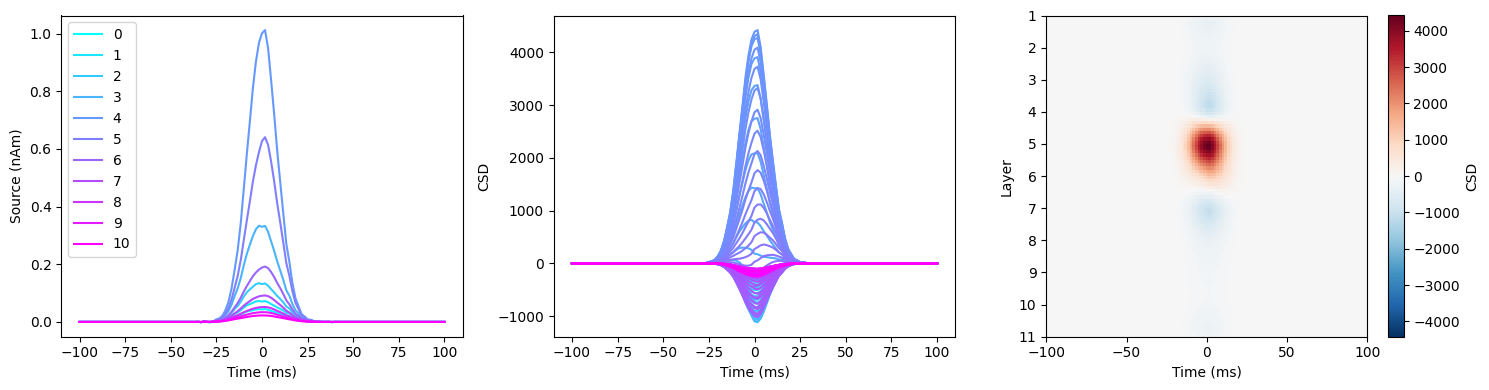

In [21]:
load_and_plot_csd(sim_fname_2, surf_set, layer_verts, layer_dists)

We can observe that with simultaneous (correlated) sources, we reconstruct a source in the middle layer. This issue also occurs with the free energy model comparison approach, with the surface in the middle of the two simulated layers being the model with the highest likelihood.

### Inversion with EBBlayer

To counteract this behavior which is a common issue with beamformers, we developed a new source reconstruction algorithm based on the implementation of EBB for correlated sources [O’Neill, G.C., Barry, D.N., Tierney, T.M. et al. Testing covariance models for MEG source reconstruction of hippocampal activity. Sci Rep 11, 17615 (2021).](https://doi.org/10.1038/s41598-021-96933-0).
Our mesh has a specific shape of Nlayers x Nvertices, and leadfields within cortical column are highly correlated because dipole orientations are the same across layers (link vectors). We therefore need to take this structure into account: 

For this 3 spatial source priors will be used: 
- an independent prior: a non-zero covariance prior for vertices with the same surface index (but same "cortical column")
- a correlated sum prior: for each layer pair, we create a combined lead field (q+=la+lb)
- a correlated depth contrast prior: for each pair of potential layer sources, we create the difference lead field (q-=la-lb)

In [22]:
# Inverting with this layer ebb is (about 2 times longer than standard EBB)
[_,_] = invert_sliding_window_ebb_layer(
    sim_fname_2, 
    surf_set, 
    patch_size=patch_size, 
    n_temp_modes=n_temp_modes,
    win_size=25,
    win_overlap=True,
    spm_instance=spm
)

Smoothing ../test_data/fs/sub-104/surf/laminar/multilayer.11.ds.link_vector.fixed.gii

smoothmeshname =

    '../test_data/fs/sub-104/surf/laminar/FWHM5.00_multilayer.11.ds.link_vector.fixed.mat'


Found smoothfile ../test_data/fs/sub-104/surf/laminar/FWHM5.00_multilayer.11.ds.link_vector.fixed.mat, not recomputing
Removed 0 bad channels

Taking random selections of 0.00 percent of channels
Using 0 spatial modes

Preparing modes file  block 1 of 1 for 274 training and 0 test chans

 saving spatial mode file /home/bonaiuto/tmp/tmp4mj9bd0q/msim2_10561_pspm-converted_autoreject-sub-104-ses-01-001-btn_trial-epo_testmodes.mat
SPM, version dev (standalone)
MATLAB, version 9.6.0.1472908 (R2019a) Update 9
 ___  ____  __  __                                            
/ __)(  _ \(  \/  )                                           
\__ \ )___/ )    (   Statistical Parametric Mapping           
(___/(__)  (_/\/\_)  SPM - https://www.fil.ion.ucl.ac.uk/spm/



---------------------------------------

Number of samples 15
  ReML Iteration 1                      :        ...2.073444e+01 [+4.12]
  ReML Iteration 2                      :        ...9.195746e+00 [+4.25]
  ReML Iteration 3                      :        ...3.065153e+00 [+4.38]
  ReML Iteration 4                      :        ...5.208948e-01 [+4.50]
  ReML Iteration 5                      :        ...2.262117e-02 [+4.62]
  ReML Iteration 6                      :        ...5.635303e-05 [+4.75]
Percent variance explained 8.51 (6.18)
Number of samples 14
Using 4 temporal modes, accounting for 73.33 percent average variance
NB smooth correlated source EBB algorithm !
trace(LQpL): ind=2.99e+08, sum=3e+08, diff=2.9e+08
Using 3 spatial source priors provided
  ReML Iteration 1                      :        ...3.727779e+01 [+4.12]
  ReML Iteration 2                      :        ...1.958167e+01 [+4.25]
  ReML Iteration 3                      :        ...8.132508e+00 [+4.38]
  ReML Iteration 4                      :        ...2.1453

  ReML Iteration 1                      :        ...2.302484e+01 [+4.12]
  ReML Iteration 2                      :        ...1.335427e+01 [+4.25]
  ReML Iteration 3                      :        ...6.427625e+00 [+4.38]
  ReML Iteration 4                      :        ...2.610254e+00 [+4.50]
  ReML Iteration 5                      :        ...7.570414e-02 [+4.62]
  ReML Iteration 6                      :        ...6.039496e-06 [+4.75]
Percent variance explained 1.04 (0.80)
Using 4 temporal modes, accounting for 90.41 percent average variance
NB smooth correlated source EBB algorithm !
trace(LQpL): ind=3.03e+08, sum=3.05e+08, diff=2.98e+08
Number of samples 14
  ReML Iteration 1                      :        ...2.325885e+01 [+4.12]
  ReML Iteration 2                      :        ...1.154603e+01 [+4.25]
  ReML Iteration 3                      :        ...3.114429e+00 [+4.38]
  ReML Iteration 4                      :        ...1.529237e-01 [+4.50]
  ReML Iteration 5                      :

Using 3 spatial source priors provided
  ReML Iteration 1                      :        ...3.706110e+01 [+4.12]
  ReML Iteration 2                      :        ...2.278134e+01 [+4.25]
  ReML Iteration 3                      :        ...1.174443e+01 [+4.38]
  ReML Iteration 4                      :        ...4.885519e+00 [+4.50]
  ReML Iteration 5                      :        ...9.547341e-01 [+4.62]
  ReML Iteration 6                      :        ...5.050118e-03 [+4.75]
hp: ind=1.93e-09, sum=1.92e-09, diff=3.38e-09
eff_i: ind=0.587, sum=0.586, diff=1.02
Inverting subject 1
  ReML Iteration 1                      :        ...1.927159e+01 [+4.12]
  ReML Iteration 2                      :        ...8.131859e+00 [+4.25]
  ReML Iteration 3                      :        ...3.075709e+00 [+4.38]
  ReML Iteration 4                      :        ...7.984327e-01 [+4.50]
  ReML Iteration 5                      :        ...9.934616e-02 [+4.62]
  ReML Iteration 6                      :        ...3

  ReML Iteration 1                      :        ...2.014609e+01 [+4.12]
  ReML Iteration 2                      :        ...1.072759e+01 [+4.25]
  ReML Iteration 3                      :        ...4.807738e+00 [+4.38]
  ReML Iteration 4                      :        ...1.532498e+00 [+4.50]
  ReML Iteration 5                      :        ...2.815925e-01 [+4.62]
  ReML Iteration 6                      :        ...1.360380e-02 [+4.75]
  ReML Iteration 7                      :        ...4.287454e-07 [+4.88]
Percent variance explained 2.59 (1.93)
Using 4 temporal modes, accounting for 74.59 percent average variance
NB smooth correlated source EBB algorithm !
trace(LQpL): ind=3.14e+08, sum=3.14e+08, diff=2.91e+08
Number of samples 14
Number of samples 14
  ReML Iteration 1                      :        ...2.188912e+01 [+4.12]
  ReML Iteration 2                      :        ...1.010810e+01 [+4.25]
  ReML Iteration 3                      :        ...3.146742e+00 [+4.38]
  ReML Iteration 4  

...

  ReML Iteration 1                      :        ...1.732218e+02 [+4.12]
  ReML Iteration 2                      :        ...1.631997e+02 [+4.25]
  ReML Iteration 3                      :        ...1.511807e+02 [+4.38]
  ReML Iteration 4                      :        ...1.343626e+02 [+4.50]
  ReML Iteration 5                      :        ...2.245804e+01 [+4.62]
  ReML Iteration 6                      :        ...5.156253e-02 [+4.75]
  ReML Iteration 7                      :        ...1.087282e-02 [+4.88]
  ReML Iteration 8                      :        ...2.116969e-03 [+5.00]
Percent variance explained 99.89 (99.67)
Number of samples 14
Fixed number of temporal modes
Using 4 temporal modes, accounting for 99.32 percent average variance
NB smooth correlated source EBB algorithm !
trace(LQpL): ind=6.14e+05, sum=7.03e+05, diff=1.07e+07
Number of samples 14
Fixed number of temporal modes
Using 4 temporal modes, accounting for 79.22 percent average variance
NB smooth correlated source EBB 

Number of samples 14
Fixed number of temporal modes
Using 4 temporal modes, accounting for 70.69 percent average variance
NB smooth correlated source EBB algorithm !
trace(LQpL): ind=2.79e+08, sum=2.8e+08, diff=2.78e+08
Using 3 spatial source priors provided
  ReML Iteration 1                      :        ...3.520241e+01 [+4.12]
  ReML Iteration 2                      :        ...2.076254e+01 [+4.25]
  ReML Iteration 3                      :        ...1.028701e+01 [+4.38]
  ReML Iteration 4                      :        ...3.709802e+00 [+4.50]
  ReML Iteration 5                      :        ...5.561099e-01 [+4.62]
  ReML Iteration 6                      :        ...9.161377e-02 [+4.75]
  ReML Iteration 7                      :        ...1.928811e-01 [+3.75]
  ReML Iteration 8                      :        ...5.694987e-05 [+3.88]
hp: ind=4.28e-09, sum=4.29e-09, diff=4.46e-09
eff_i: ind=1.19, sum=1.2, diff=1.24
Inverting subject 1
  ReML Iteration 1                      :        ...2.0

Using 3 spatial source priors provided
  ReML Iteration 1                      :        ...3.456850e+01 [+4.12]
  ReML Iteration 2                      :        ...2.037585e+01 [+4.25]
  ReML Iteration 3                      :        ...1.060580e+01 [+4.38]
  ReML Iteration 4                      :        ...4.640294e+00 [+4.50]
  ReML Iteration 5                      :        ...1.357347e+00 [+4.62]
  ReML Iteration 6                      :        ...1.627581e-02 [+4.75]
  ReML Iteration 7                      :        ...5.883446e-07 [+4.88]
hp: ind=3.01e-09, sum=3e-09, diff=4.11e-09
eff_i: ind=0.883, sum=0.884, diff=1.16
Inverting subject 1
  ReML Iteration 1                      :        ...1.943372e+01 [+4.12]
  ReML Iteration 2                      :        ...9.506569e+00 [+4.25]
  ReML Iteration 3                      :        ...4.170556e+00 [+4.38]
  ReML Iteration 4                      :        ...1.711237e+00 [+4.50]
  ReML Iteration 5                      :        ...6.76

  ReML Iteration 2                      :        ...2.597160e+01 [+4.25]
  ReML Iteration 3                      :        ...1.526073e+01 [+4.38]
  ReML Iteration 4                      :        ...6.971200e+00 [+4.50]
  ReML Iteration 5                      :        ...1.654402e-01 [+4.62]
  ReML Iteration 6                      :        ...3.215840e-05 [+4.75]
hp: ind=1.78e-09, sum=1.75e-09, diff=1.86e-09
eff_i: ind=0.557, sum=0.557, diff=0.533
Inverting subject 1
  ReML Iteration 1                      :        ...2.313258e+01 [+4.12]
  ReML Iteration 2                      :        ...1.444892e+01 [+4.25]
  ReML Iteration 3                      :        ...7.473538e+00 [+4.38]
  ReML Iteration 4                      :        ...3.053937e+00 [+4.50]
  ReML Iteration 5                      :        ...1.336061e-01 [+4.62]
  ReML Iteration 6                      :        ...2.043030e-05 [+4.75]
Percent variance explained 0.56 (0.53)
Using 4 temporal modes, accounting for 76.01 percent

IdleTimeout has been reached.
Parallel pool using the 'local' profile is shutting down.
20-Mar-2026 04:32:04 - Done    'Source inversion, iterative'
20-Mar-2026 04:32:04 - Done



No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 5.108969774506914e-19


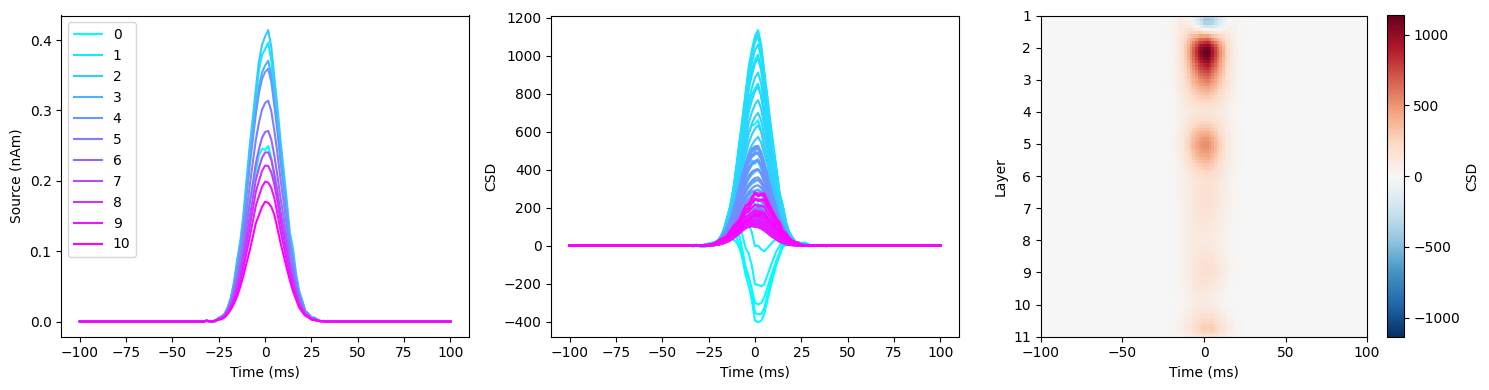

In [23]:
load_and_plot_csd(sim_fname_2, surf_set, layer_verts, layer_dists)

EBB layer can then reconstruct 2 simultaneous sources.

In [24]:
spm.terminate()

shutil.rmtree(tmp_dir)